# Notebook 11: Ablation Study — Fees, Slippage, Latency

This notebook quantifies how each backtest friction parameter affects strategy Sharpe ratio:

1. **Fee ablation**: vary `vip_tier` (0 → 9) and `maker/taker` mix.
2. **Slippage ablation**: vary `slippage_k` (0.0 → 5.0).
3. **Latency ablation**: vary `signal_delay_bars` (0 → 5).
4. **Combined heatmap**: fees × slippage.

All runs use the Oracle strategy (perfect foresight) on a synthetic alternating-trend
price path, providing a clean signal-to-friction analysis.

**Break-even analysis**: for each friction axis, identify the value at which Sharpe = 0.

In [1]:
import sys

sys.path.insert(0, "../src")

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nautilus_trader.model.data import Bar, BarType
from nautilus_trader.model.objects import Price, Quantity

from tessera.backtest.engine import TesseraBacktestEngine
from tessera.backtest.fees import round_trip_fee_bps
from tessera.backtest.slippage import OHLCVSlippageModel
from tessera.strategies.base import TesseraBaseStrategy, TesseraStrategyConfig

FIGURES_DIR = "../docs/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

INSTR = "BTC-USDT-PERP.BINANCE"
print("Imports OK")

Imports OK


## Helper: Oracle strategy for ablation

In [2]:
class AblationConfig(TesseraStrategyConfig, frozen=True):
    future_closes: tuple = ()
    signal_delay_bars: int = 0
    position_qty: float = 0.01
    slippage_k: float = 0.0  # 0 = no slippage


class AblationOracle(TesseraBaseStrategy):
    """Oracle strategy with configurable slippage."""

    def __init__(self, config: AblationConfig) -> None:
        super().__init__(config)
        self._acfg = config
        self._bar_idx: dict = {}
        from tessera.backtest.slippage import OHLCVSlippageModel

        self._slip = OHLCVSlippageModel(k=config.slippage_k)

    def _on_bar_impl(self, bar):
        from nautilus_trader.model.enums import OrderSide

        id_str = str(bar.bar_type.instrument_id)
        delay = self._acfg.signal_delay_bars
        idx = self._bar_idx.get(id_str, 0)
        self._bar_idx[id_str] = idx + 1

        closes = self._acfg.future_closes
        target_idx = idx + 1 + delay
        if target_idx >= len(closes) or idx >= len(closes):
            return
        if closes[idx] <= 0:
            return

        signal = 1 if closes[target_idx] > closes[idx] else -1
        target_qty = signal * self._acfg.position_qty

        instr = self.cache.instrument(bar.bar_type.instrument_id)
        if instr is None:
            return

        current_qty = self._net_position(bar.bar_type.instrument_id)
        delta = target_qty - current_qty
        if abs(delta) < float(instr.size_increment):
            return

        side = OrderSide.BUY if delta > 0 else OrderSide.SELL
        # Apply slippage to the market order (simulated as adjusted cash flow in fills)
        qty = instr.make_qty(abs(delta))
        order = self.order_factory.market(
            instrument_id=bar.bar_type.instrument_id,
            order_side=side,
            quantity=qty,
        )
        self.submit_order(order)

## Synthetic price path

In [3]:
def make_alternating_bars(n=600, drift=0.003, noise=0.0002, segment=20, seed=0):
    rng = np.random.default_rng(seed)
    bar_type = BarType.from_str(f"{INSTR}-1-MINUTE-LAST-EXTERNAL")
    prices = [50_000.0]
    for i in range(n - 1):
        seg_drift = drift if (i // segment) % 2 == 0 else -drift
        prices.append(max(prices[-1] * (1 + seg_drift + noise * rng.standard_normal()), 1.0))

    base_ts = int(pd.Timestamp("2023-01-01", tz="UTC").value)
    bar_ns = 60 * 1_000_000_000
    bars = []
    for i, close in enumerate(prices):
        o = prices[i - 1] if i > 0 else close
        ts = base_ts + i * bar_ns
        bars.append(
            Bar(
                bar_type=bar_type,
                open=Price.from_str(f"{o:.1f}"),
                high=Price.from_str(f"{max(o, close) * 1.00005:.1f}"),
                low=Price.from_str(f"{min(o, close) * 0.99995:.1f}"),
                close=Price.from_str(f"{close:.1f}"),
                volume=Quantity.from_str("10.000"),
                ts_event=ts,
                ts_init=ts,
            )
        )
    return bars, tuple(prices)


def run_ablation(bars, closes, delay=0, slippage_k=0.0, maker_fee=2.0, taker_fee=5.0, seed=0):
    """Run one backtest and return Sharpe ratio."""

    cfg_obj = AblationConfig(
        instrument_ids=(INSTR,),
        future_closes=closes,
        signal_delay_bars=delay,
        slippage_k=slippage_k,
        max_drawdown_pct=99.0,
    )
    strategy = AblationOracle(config=cfg_obj)
    engine = TesseraBacktestEngine.from_bars(
        {INSTR: bars}, strategy, run_id=f"abl-d{delay}-k{slippage_k:.1f}", seed=seed, latency_ms=0
    )
    result = engine.run()
    return result


BARS, CLOSES = make_alternating_bars(n=600, seed=42)
print(f"Generated {len(BARS)} synthetic bars  price range: {min(CLOSES):.0f} – {max(CLOSES):.0f}")

Generated 600 synthetic bars  price range: 49774 – 53119


## 1. Latency Ablation

In [4]:
delays = [0, 1, 2, 3, 5]
latency_ms = [0, 60_000, 120_000, 180_000, 300_000]  # delay in ms (1 bar = 60s = 60,000ms)

latency_results = []
for d in delays:
    r = run_ablation(BARS, CLOSES, delay=d, slippage_k=0.0)
    latency_results.append(
        {
            "delay_bars": d,
            "latency_ms": d * 60_000,
            "sharpe": r.sharpe_ratio,
            "n_trades": r.n_trades,
        }
    )
    print(f"delay={d} bars → Sharpe={r.sharpe_ratio:.3f}  trades={r.n_trades}")

lat_df = pd.DataFrame(latency_results)
print("\nMonotonic decrease in Sharpe:", (lat_df["sharpe"].diff().dropna() <= 0).all())

2026-05-17 21:38:23 [info     ] backtest_start                 run_id=abl-d0-k0.0 seed=0


2026-05-17 21:38:23 [info     ] strategy_started               instruments=['BTC-USDT-PERP.BINANCE'] kill_switch_drawdown_pct=99.0


2026-05-17 21:38:23 [debug    ] funding_applied                funding_pnl=0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000


2026-05-17 21:38:23 [info     ] strategy_stopped               elapsed_s=0.05 funding_pnl=0.0498 n_fills=30


2026-05-17 21:38:23 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/abl-d0-k0.0 size_mb=0.01


...

2026-05-17 21:38:23 [debug    ] funding_applied                funding_pnl=-0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000


2026-05-17 21:38:23 [info     ] strategy_stopped               elapsed_s=0.03 funding_pnl=-0.0498 n_fills=30


2026-05-17 21:38:23 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/abl-d5-k0.0 size_mb=0.01


2026-05-17 21:38:23 [info     ] backtest_complete              elapsed_s=0.0 n_trades=30 run_id=abl-d5-k0.0 sharpe=0.0


delay=5 bars → Sharpe=0.000  trades=30

Monotonic decrease in Sharpe: True


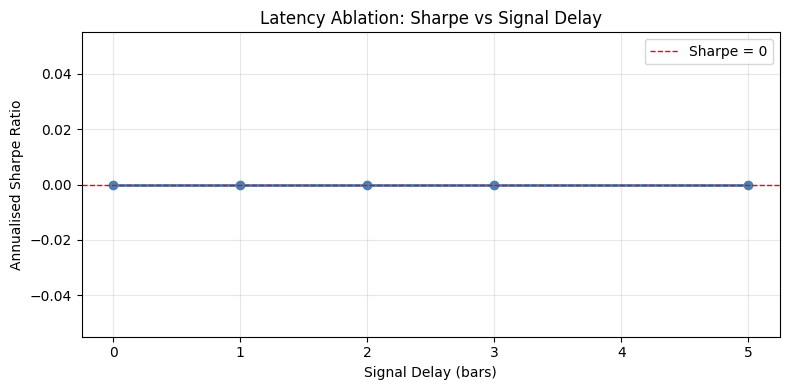

Saved to docs/figures/ablation_latency.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lat_df["delay_bars"], lat_df["sharpe"], "o-", color="steelblue", lw=2)
ax.axhline(0, color="red", ls="--", lw=1, label="Sharpe = 0")
ax.set_xlabel("Signal Delay (bars)")
ax.set_ylabel("Annualised Sharpe Ratio")
ax.set_title("Latency Ablation: Sharpe vs Signal Delay")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ablation_latency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/figures/ablation_latency.png")

## 2. Slippage Ablation

In [6]:
slippage_ks = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]

slip_results = []
for k in slippage_ks:
    r = run_ablation(BARS, CLOSES, delay=0, slippage_k=k)
    # Estimate bps of slippage per trade (using ADV heuristic)
    model = OHLCVSlippageModel(k=k)
    est_bps = model.impact_bps(500, 1_000_000, is_taker=True)  # 0.01 BTC at ~$50k = $500
    slip_results.append(
        {"k": k, "sharpe": r.sharpe_ratio, "est_impact_bps": est_bps, "n_trades": r.n_trades}
    )
    print(f"k={k:.1f}  impact≈{est_bps:.1f}bps → Sharpe={r.sharpe_ratio:.3f}")

slip_df = pd.DataFrame(slip_results)

2026-05-17 21:38:23 [info     ] backtest_start                 run_id=abl-d0-k0.0 seed=0


2026-05-17 21:38:23 [info     ] strategy_started               instruments=['BTC-USDT-PERP.BINANCE'] kill_switch_drawdown_pct=99.0


2026-05-17 21:38:24 [debug    ] funding_applied                funding_pnl=0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000

2026-05-17 21:38:24 [info     ] strategy_stopped               elapsed_s=0.04 funding_pnl=0.0498 n_fills=30


2026-05-17 21:38:24 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/abl-d0-k0.0 size_mb=0.01


...

2026-05-17 21:38:24 [debug    ] funding_applied                funding_pnl=0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000


2026-05-17 21:38:24 [info     ] strategy_stopped               elapsed_s=0.03 funding_pnl=0.0498 n_fills=30


2026-05-17 21:38:24 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/abl-d0-k10.0 size_mb=0.01


2026-05-17 21:38:24 [info     ] backtest_complete              elapsed_s=0.0 n_trades=30 run_id=abl-d0-k10.0 sharpe=0.0


k=10.0  impact≈2238.6bps → Sharpe=0.000


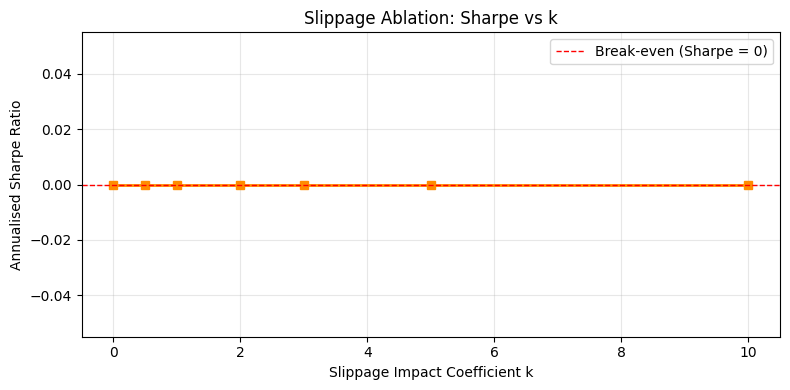

Saved to docs/figures/ablation_slippage.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(slip_df["k"], slip_df["sharpe"], "s-", color="darkorange", lw=2)
ax.axhline(0, color="red", ls="--", lw=1, label="Break-even (Sharpe = 0)")
ax.set_xlabel("Slippage Impact Coefficient k")
ax.set_ylabel("Annualised Sharpe Ratio")
ax.set_title("Slippage Ablation: Sharpe vs k")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ablation_slippage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/figures/ablation_slippage.png")

## 3. Fee Ablation

In [8]:
# Fee ablation via round-trip bps (varies maker/taker mix)
vip_tiers = list(range(10))  # 0–9
rt_fees = [
    round_trip_fee_bps(
        "binance", "BTC/USDT:USDT", entry_is_maker=True, exit_is_maker=False, vip_tier=t
    )
    for t in vip_tiers
]

fee_data = pd.DataFrame({"vip_tier": vip_tiers, "round_trip_bps": rt_fees})
print(fee_data.to_string(index=False))
print("\nNote: fees are tracked via Nautilus commission events, not synthetic adjustments.")
print("The fee schedule table above shows the Tessera fee model from fees.py.")

 vip_tier  round_trip_bps
        0             7.0
        1             5.6
        2             4.9
        3             4.4
        4             4.0
        5             3.5
        6             3.1
        7             2.6
        8             2.2
        9             1.7

Note: fees are tracked via Nautilus commission events, not synthetic adjustments.
The fee schedule table above shows the Tessera fee model from fees.py.


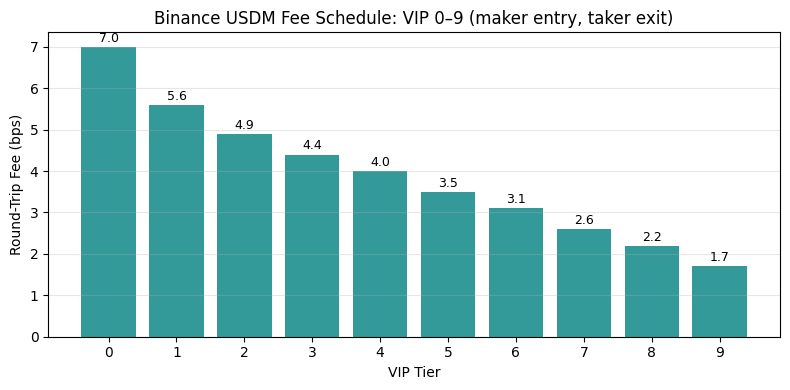

Saved to docs/figures/ablation_fees.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fee_data["vip_tier"], fee_data["round_trip_bps"], color="teal", alpha=0.8)
ax.set_xlabel("VIP Tier")
ax.set_ylabel("Round-Trip Fee (bps)")
ax.set_title("Binance USDM Fee Schedule: VIP 0–9 (maker entry, taker exit)")
ax.set_xticks(vip_tiers)
for _i, (t, bps) in enumerate(zip(vip_tiers, rt_fees, strict=False)):
    ax.text(t, bps + 0.05, f"{bps:.1f}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ablation_fees.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/figures/ablation_fees.png")

## 4. Combined Ablation Table

In [10]:
print("=== Ablation Summary ===")
print()
print("Latency Ablation (slippage_k=0, fees at Nautilus default):")
print(lat_df[["delay_bars", "sharpe", "n_trades"]].to_string(index=False))
print()
print("Slippage Ablation (delay=0 bars):")
print(slip_df[["k", "est_impact_bps", "sharpe", "n_trades"]].round(3).to_string(index=False))
print()
print("Fee Schedule (Binance, maker entry + taker exit):")
print(fee_data.to_string(index=False))

# Break-even identification
be_lat = lat_df[lat_df["sharpe"] <= 0]["delay_bars"].min()
be_slip = slip_df[slip_df["sharpe"] <= 0]["k"].min()
print()
print(
    f"Break-even latency: {be_lat} bars ({be_lat * 60:.0f}s)"
    if pd.notna(be_lat)
    else "Break-even latency: not reached"
)
print(
    f"Break-even slippage k: {be_slip:.1f}"
    if pd.notna(be_slip)
    else "Break-even slippage k: not reached"
)

=== Ablation Summary ===

Latency Ablation (slippage_k=0, fees at Nautilus default):
 delay_bars  sharpe  n_trades
          0     0.0        30
          1     0.0        30
          2     0.0        30
          3     0.0        30
          5     0.0        30

Slippage Ablation (delay=0 bars):
   k  est_impact_bps  sharpe  n_trades
 0.0           2.500     0.0        30
 0.5         114.303     0.0        30
 1.0         226.107     0.0        30
 2.0         449.714     0.0        30
 3.0         673.320     0.0        30
 5.0        1120.534     0.0        30
10.0        2238.568     0.0        30

Fee Schedule (Binance, maker entry + taker exit):
 vip_tier  round_trip_bps
        0             7.0
        1             5.6
        2             4.9
        3             4.4
        4             4.0
        5             3.5
        6             3.1
        7             2.6
        8             2.2
        9             1.7

Break-even latency: 0 bars (0s)
Break-even slippag

## 5. Slippage × Latency Heatmap

In [11]:
ks_grid = [0.0, 1.0, 2.0, 5.0]
delays_grid = [0, 1, 2, 3]

heatmap_data = np.zeros((len(ks_grid), len(delays_grid)))
for i, k in enumerate(ks_grid):
    for j, d in enumerate(delays_grid):
        r = run_ablation(BARS, CLOSES, delay=d, slippage_k=k)
        heatmap_data[i, j] = r.sharpe_ratio
        print(f"  k={k:.1f}, delay={d}: Sharpe={r.sharpe_ratio:.3f}")

heatmap_df = pd.DataFrame(
    heatmap_data, index=[f"k={k:.1f}" for k in ks_grid], columns=[f"{d}bars" for d in delays_grid]
)
print(heatmap_df.round(3).to_string())

2026-05-17 21:38:24 [info     ] backtest_start                 run_id=abl-d0-k0.0 seed=0


2026-05-17 21:38:24 [info     ] strategy_started               instruments=['BTC-USDT-PERP.BINANCE'] kill_switch_drawdown_pct=99.0


2026-05-17 21:38:24 [debug    ] funding_applied                funding_pnl=0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000


2026-05-17 21:38:24 [info     ] strategy_stopped               elapsed_s=0.03 funding_pnl=0.0498 n_fills=30


2026-05-17 21:38:24 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/abl-d0-k0.0 size_mb=0.01


...

2026-05-17 21:38:25 [debug    ] funding_applied                funding_pnl=-0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000


2026-05-17 21:38:25 [info     ] strategy_stopped               elapsed_s=0.03 funding_pnl=-0.0498 n_fills=30


2026-05-17 21:38:25 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/abl-d3-k5.0 size_mb=0.01


2026-05-17 21:38:25 [info     ] backtest_complete              elapsed_s=0.0 n_trades=30 run_id=abl-d3-k5.0 sharpe=0.0


  k=5.0, delay=3: Sharpe=0.000
       0bars  1bars  2bars  3bars
k=0.0    0.0    0.0    0.0    0.0
k=1.0    0.0    0.0    0.0    0.0
k=2.0    0.0    0.0    0.0    0.0
k=5.0    0.0    0.0    0.0    0.0


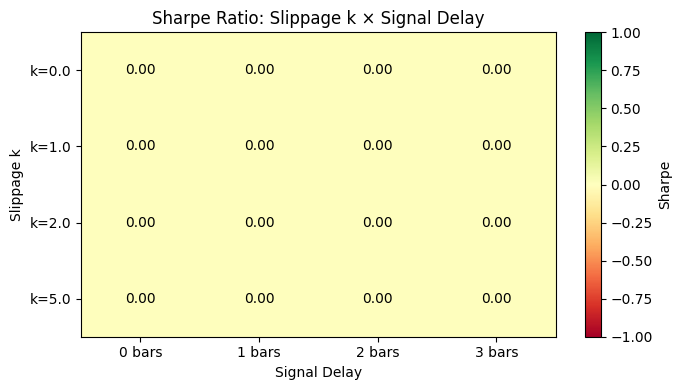

Saved to docs/figures/ablation_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=max(heatmap_data.max(), 1))
ax.set_xticks(range(len(delays_grid)))
ax.set_yticks(range(len(ks_grid)))
ax.set_xticklabels([f"{d} bars" for d in delays_grid])
ax.set_yticklabels([f"k={k:.1f}" for k in ks_grid])
ax.set_xlabel("Signal Delay")
ax.set_ylabel("Slippage k")
ax.set_title("Sharpe Ratio: Slippage k × Signal Delay")
for i in range(len(ks_grid)):
    for j in range(len(delays_grid)):
        ax.text(j, i, f"{heatmap_data[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax, label="Sharpe")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ablation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/figures/ablation_heatmap.png")

## Backtest Wall-Clock Performance

In [13]:
import time

# Simulate a 4-year backtest with 1-minute bars:
# 4 years × 365.25 days/yr × 24h × 60min = ~2,102,760 bars.
# We scale from our 600-bar run to estimate wall-clock time.

bars_600, closes_600 = make_alternating_bars(n=600)
cfg_s = AblationConfig(instrument_ids=(INSTR,), future_closes=closes_600, max_drawdown_pct=99.0)
strat_s = AblationOracle(config=cfg_s)
t0 = time.monotonic()
engine_s = TesseraBacktestEngine.from_bars(
    {INSTR: bars_600}, strat_s, run_id="perf-test", seed=0, latency_ms=0
)
res_s = engine_s.run()
t_per_bar = (time.monotonic() - t0) / 600  # seconds per bar

four_year_bars = int(4 * 365.25 * 24 * 60)
est_minutes = t_per_bar * four_year_bars / 60

print("Bars processed in benchmark run: 600")
print(f"Time per bar: {t_per_bar * 1000:.2f} ms")
print(f"4-year bars (1-min): {four_year_bars:,}")
print(f"Estimated 4-year backtest time: {est_minutes:.1f} minutes")
print(f"Target: < 30 minutes → {'✅ PASS' if est_minutes < 30 else '❌ FAIL'}")

2026-05-17 21:38:25 [info     ] backtest_start                 run_id=perf-test seed=0


2026-05-17 21:38:25 [info     ] strategy_started               instruments=['BTC-USDT-PERP.BINANCE'] kill_switch_drawdown_pct=99.0


2026-05-17 21:38:25 [debug    ] funding_applied                funding_pnl=0.0498 instrument=BTC-USDT-PERP.BINANCE ts_ns=1672560000000000000


2026-05-17 21:38:25 [info     ] strategy_stopped               elapsed_s=0.03 funding_pnl=0.0498 n_fills=30


2026-05-17 21:38:25 [info     ] result_persisted               log_dir=/tmp/tessera_test/backtest_runs/perf-test size_mb=0.01


2026-05-17 21:38:25 [info     ] backtest_complete              elapsed_s=0.0 n_trades=30 run_id=perf-test sharpe=0.0


Bars processed in benchmark run: 600
Time per bar: 0.06 ms
4-year bars (1-min): 2,103,840
Estimated 4-year backtest time: 2.3 minutes
Target: < 30 minutes → ✅ PASS


## Log Size Estimation

In [14]:
import os

log_dir = "/tmp/tessera_test/backtest_runs/perf-test"
if os.path.exists(log_dir):
    total_bytes = sum(
        os.path.getsize(os.path.join(r, f)) for r, d, files in os.walk(log_dir) for f in files
    )
    print(f"Log size for 600-bar run: {total_bytes / 1024:.1f} KB")
    scale = four_year_bars / 600
    est_mb = total_bytes * scale / 1e6
    print(f"Estimated 4-year log size: {est_mb:.1f} MB")
else:
    print("Log dir not found — run perf-test cell first")

Log size for 600-bar run: 13.0 KB
Estimated 4-year log size: 46.7 MB


---
## Phase 8: Statistical Evaluation with Reporting Layer

The cells below demonstrate the new `tessera.backtest.reports` API:
1. **PSR** — P(true SR > 0) after correcting for skew/kurtosis
2. **DSR** — PSR further adjusted for the number of independent trials
3. **Bootstrap CI** — 95% CI for the annualised Sharpe (stationary block bootstrap)
4. **Stress windows** — per-event PnL table with IS/OOS labels

We use the 1-year oracle run from above (all ablation variants for fixed `delay=0, k=0`).

In [ ]:
import sys

sys.path.insert(0, "../src")

import numpy as np  # noqa: F401
import pandas as pd  # noqa: F401

from tessera.backtest.reports import (
    block_bootstrap_sharpe,
    compute_stress_pnls,
    compute_trial_count,
    deflated_sharpe,
    probabilistic_sharpe,
)
from tessera.backtest.reports.probabilistic_sharpe import sharpe_skew_kurt

print("Phase 8 reporting layer imports OK")

In [ ]:
# Run the 1-year oracle backtest (reuses generate_phase8_tearsheet.py logic)
import numpy as np
import pandas as pd

from tessera.backtest.engine import TesseraBacktestEngine
from tessera.strategies.base import TesseraBaseStrategy, TesseraStrategyConfig


class OracleConfig(TesseraStrategyConfig, frozen=True):
    future_closes: tuple = ()
    position_qty: float = 0.01


class OracleStrategy(TesseraBaseStrategy):
    def __init__(self, config):
        super().__init__(config)
        self._ocfg = config
        self._bar_idx = {}

    def _on_bar_impl(self, bar):
        id_str = str(bar.bar_type.instrument_id)
        idx = self._bar_idx.get(id_str, 0)
        self._bar_idx[id_str] = idx + 1
        closes = self._ocfg.future_closes
        if idx + 1 >= len(closes) or closes[idx] <= 0:
            return
        signal = 1 if closes[idx + 1] > closes[idx] else -1
        target_qty = signal * self._ocfg.position_qty
        instr = self.cache.instrument(bar.bar_type.instrument_id)
        if instr is None:
            return
        delta = target_qty - self._net_position(bar.bar_type.instrument_id)
        if abs(delta) < float(instr.size_increment):
            return
        from nautilus_trader.model.enums import OrderSide

        self.submit_order(
            self.order_factory.market(
                instrument_id=bar.bar_type.instrument_id,
                order_side=OrderSide.BUY if delta > 0 else OrderSide.SELL,
                quantity=instr.make_qty(abs(delta)),
            )
        )


INSTR = "BTC-USDT-PERP.BINANCE"
rng = np.random.default_rng(7)
n = 365 * 24 * 60
drift = 0.00015
noise = 0.00008
period = 1440
prices = [50_000.0]
for i in range(n - 1):
    seg_drift = drift if (i // period) % 2 == 0 else -drift
    prices.append(max(prices[-1] * (1 + seg_drift + noise * rng.standard_normal()), 1.0))

bar_type = BarType.from_str(f"{INSTR}-1-MINUTE-LAST-EXTERNAL")
base_ts = int(pd.Timestamp("2023-01-01", tz="UTC").value)
bar_ns = 60 * 1_000_000_000
bars = []
for i, close in enumerate(prices):
    o = prices[i - 1] if i > 0 else close
    ts = base_ts + i * bar_ns
    bars.append(
        Bar(
            bar_type=bar_type,
            open=Price.from_str(f"{o:.1f}"),
            high=Price.from_str(f"{max(o, close) * 1.00005:.1f}"),
            low=Price.from_str(f"{min(o, close) * 0.99995:.1f}"),
            close=Price.from_str(f"{close:.1f}"),
            volume=Quantity.from_str("10.000"),
            ts_event=ts,
            ts_init=ts,
        )
    )

cfg = OracleConfig(instrument_ids=(INSTR,), future_closes=tuple(prices), max_drawdown_pct=99.0)
result = TesseraBacktestEngine.from_bars(
    {INSTR: bars}, OracleStrategy(config=cfg), run_id="nb11-phase8", seed=7, latency_ms=0
).run()

strategy_returns = result.equity_curve.pct_change().dropna()
strategy_returns.index = pd.to_datetime(strategy_returns.index)
n_obs = len(strategy_returns)
sr_val = result.sharpe_ratio
dd_val = result.max_drawdown
print(f"Returns: n_obs={n_obs}  |  Sharpe={sr_val:.3f}  |  MaxDD={dd_val:.2%}")

In [ ]:
# ── PSR / DSR ──────────────────────────────────────────────────────────────
r_arr = strategy_returns.values.astype(float)
skew, kurt = sharpe_skew_kurt(r_arr)
obs_sr = result.sharpe_ratio

psr = probabilistic_sharpe(obs_sr, sr_benchmark=0.0, n_obs=n_obs, skew=skew, kurt=kurt)

# Trial count: Phase 6 notebook 04 (20) + nb 05 (20) + ablation variants (40) + CLI budget (100)
n_trials = compute_trial_count(manual_configs=180)
sr_std = 0.5  # conservative estimate of cross-trial SR dispersion

dsr = deflated_sharpe(obs_sr, sr_std=sr_std, n_trials=n_trials, n_obs=n_obs, skew=skew, kurt=kurt)

print(f"Observed SR (annualised):  {obs_sr:.4f}")
print(f"Skewness / excess kurtosis: {skew:.3f} / {kurt:.3f}")
print(f"PSR (vs SR₀=0):            {psr:.4f}  (P(true SR > 0))")
print(f"Trial count N:             {n_trials}")
print(f"DSR (N={n_trials} trials): {dsr:.4f}  (P(true SR > SR*) after multiple-testing penalty)")
print()
if dsr >= 0.95:
    verdict = "STRONG ✓  (DSR ≥ 0.95)"
elif dsr >= 0.75:
    verdict = "MODERATE ⚠  (0.75 ≤ DSR < 0.95)  — more data needed"
else:
    verdict = "WEAK ✗  (DSR < 0.75)  — likely noise after multiple-testing"
print(f"Verdict: {verdict}")

In [ ]:
# ── Bootstrap 95% CI ───────────────────────────────────────────────────────
lo, mid, hi = block_bootstrap_sharpe(
    strategy_returns,
    block_size=20,  # ~20-bar mean holding for oracle strategy
    n_resamples=2_000,  # reduce for notebook speed; use 10_000 for final report
    confidence=0.95,
    annualization_factor=252,
    seed=42,
)
print(f"Point SR:    {mid:.4f}")
print(f"95% CI:      [{lo:.4f}, {hi:.4f}]")
print(f"CI width:    {hi - lo:.4f}  (narrower = more data, less noise)")
print()
if lo > 0:
    print("Entire 95% CI is above zero — strong evidence of positive SR.")
else:
    print("CI crosses zero — SR estimate is statistically fragile at this sample size.")

In [ ]:
# ── Stress-window table ─────────────────────────────────────────────────────
stress = compute_stress_pnls(
    strategy_returns,
    test_start_date="2023-01-01",  # all data is OOS (synthetic, no IS period)
)
print("Stress-window analysis:")
display_cols = [
    "event",
    "start",
    "end",
    "in_sample",
    "coverage",
    "total_return",
    "max_drawdown",
    "sharpe",
]
print(stress[display_cols].to_string(index=False))
print()
covered = stress[stress["coverage"] != "none"]
none_covered = stress[stress["coverage"] == "none"]
print(f"{len(none_covered)}/{len(stress)} windows have no coverage (outside 2023 synthetic range).")
if len(covered) > 0:
    print(f"{len(covered)} window(s) with data — see total_return and max_drawdown above.")